# <center>Homework 94</center>

In [16]:
from importlib import reload
import semi_supervised_alg
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_digits
import numpy as np
import matplotlib.pyplot as plt 

## Task 1

In [8]:
X_digits, y_digits = load_digits(return_X_y=True)
X_train, y_train = X_digits[:1400], y_digits[:1400]
X_test, y_test   = X_digits[1400:], y_digits[1400:]

np.random.seed(42)
n_labeled = 50
y_train_50_lb = np.ones(len(y_train)) * -1
labeled_inxs = np.random.choice(len(y_train), n_labeled, False)
y_train_50_lb[labeled_inxs] = y_train[labeled_inxs]

In [ ]:

reload(semi_supervised_alg)
from semi_supervised_alg import SelfTrainingClassifier
custom_self_clf = SelfTrainingClassifier(RandomForestClassifier(random_state=42)).fit(X_train, y_train_50_lb)

from sklearn.semi_supervised import SelfTrainingClassifier
original_self_clf = SelfTrainingClassifier(RandomForestClassifier(random_state=42)).fit(X_train, y_train_50_lb)


print('n_iter_\n', 'Custom:', custom_self_clf.n_iter_, 'Original:', original_self_clf.n_iter_)
print('n_iter_\n', 'Custom:', custom_self_clf.transduction_, 'Original:', original_self_clf.transduction_)

print('Custom vs Original transduction_', (custom_self_clf.transduction_ == original_self_clf.transduction_).mean())

print('Custom vs Original Labels', (custom_self_clf.predict(X_train) == y_train).mean())
print('Original vs Original Labels', (original_self_clf.predict(X_train) == y_train).mean())

n_iter_
 Custom: 10 Original: 10
n_iter_
 Custom: [ 0. -1. -1. ...  4.  4.  7.] Original: [ 0. -1. -1. ...  4.  4.  7.]
Custom vs Original transduction_ 0.93
Custom vs Original Labels 0.5764285714285714
Original vs Original Labels 0.5792857142857143


In [173]:
reload(semi_supervised_alg)
from semi_supervised_alg import SelfTrainingClassifier
custom_self_clf = SelfTrainingClassifier(
    RandomForestClassifier(random_state=42), 
    criterion='k_best').fit(X_train, y_train_50_lb)

from sklearn.semi_supervised import SelfTrainingClassifier
original_self_clf = SelfTrainingClassifier(
    RandomForestClassifier(random_state=42), 
    criterion='k_best').fit(X_train, y_train_50_lb)

print('n_iter_\n', 'Custom:', custom_self_clf.n_iter_, 'Original:', original_self_clf.n_iter_)
print('Custom:', custom_self_clf.transduction_, 'Original:', original_self_clf.transduction_)

print('Custom vs Original transduction_', (custom_self_clf.transduction_ == original_self_clf.transduction_).mean())

print('Custom vs Original Labels', (custom_self_clf.predict(X_train) == y_train).mean())
print('Original vs Original Labels', (original_self_clf.predict(X_train) == y_train).mean())

n_iter_
 Custom: 10 Original: 10
Custom: [ 0. -1. -1. ... -1. -1. -1.] Original: [ 0. -1. -1. ... -1. -1. -1.]
Custom vs Original transduction_ 0.9871428571428571
Custom vs Original Labels 0.6957142857142857
Original vs Original Labels 0.6771428571428572


## Task 2

In [174]:
def plot_digit(digit, ax):
    ax.imshow(digit.reshape(8, 8), cmap='binary')
    ax.set_xticks([])
    ax.set_yticks([])

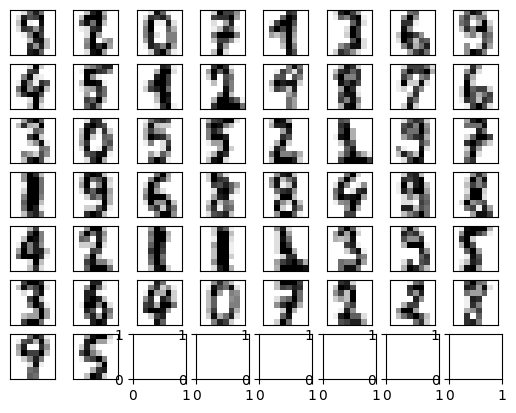

AttributeError: 'LogisticRegression' object has no attribute 'test'

In [175]:
reload(semi_supervised_alg)
from semi_supervised_alg import KMeansLearningClassifier

custom_lerning = KMeansLearningClassifier(50, 'km_50cl.pkl', plot_digit)
custom_lerning.fit(X_train)

In [50]:
reload(semi_supervised_alg)
from semi_supervised_alg import KMeansLearningClassifier

labels = np.array([5, 9, 4, 2, 9, 1, 0, 7, 4, 6, 8, 1, 2, 3, 5, 3, 1, 7, 4, 6, 0, 2, 1, 4, 
                   8, 1, 1, 9, 3, 4, 8, 8, 5, 6, 3, 5, 7, 1, 7, 9, 7, 5, 2, 7 ,9, 2, 8, 7, 0, 9])

custom_lerning = KMeansLearningClassifier(model_file_name='km_50cl.pkl').fit_labels(labels)
custom_lerning.score(X_test, y_test)

0.8916876574307305

## Task 3

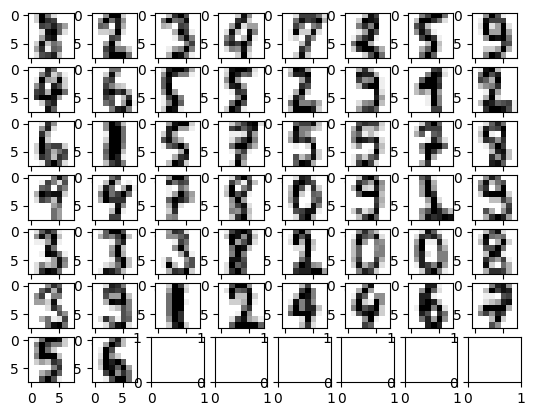

In [101]:
reload(semi_supervised_alg)
from semi_supervised_alg import ActiveLearningClassifier

actime_lern = ActiveLearningClassifier(50, 'active_50cl.pkl', plot_digit, random_state=42, test=True)
lb_inxs = actime_lern.fit(X_train)

In [102]:
labels = y_train[lb_inxs]
labels

array([8, 2, 3, 4, 7, 2, 5, 9, 4, 6, 5, 5, 2, 9, 1, 2, 6, 1, 5, 7, 5, 5,
       7, 8, 9, 4, 7, 8, 0, 9, 1, 9, 3, 3, 3, 8, 2, 0, 0, 8, 3, 9, 1, 2,
       4, 4, 6, 7, 5, 6])

In [103]:
reload(semi_supervised_alg)
from semi_supervised_alg import ActiveLearningClassifier

actime_lern = ActiveLearningClassifier(model_file_name='active_50cl.pkl')
actime_lern.fit_labels(labels)
actime_lern.score(X_test, y_test)

0.8790931989924433

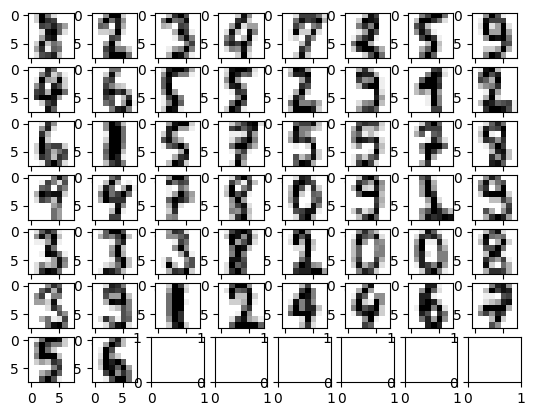

In [104]:
actime_lern = ActiveLearningClassifier(model_file_name='active_50cl.pkl')
lb_inxs = actime_lern.fit(X_train)

In [105]:
labels2 = y_train[lb_inxs]
labels2

array([3, 1, 9, 1, 1, 5, 0, 2, 5, 0, 2, 8, 6, 2, 2, 7, 6, 3, 0, 7, 4, 6,
       5, 0, 7, 6, 1, 5, 1, 5, 8, 6, 8, 5, 1, 2, 9, 0, 1, 6, 8, 6, 2, 6,
       4, 5, 9, 4, 4, 4])

In [106]:
labels == labels2

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False,  True,
       False, False, False, False, False])

In [107]:
actime_lern = ActiveLearningClassifier(model_file_name='active_50cl.pkl')
actime_lern.fit_labels(labels2)
actime_lern.score(X_test, y_test)

0.8841309823677582

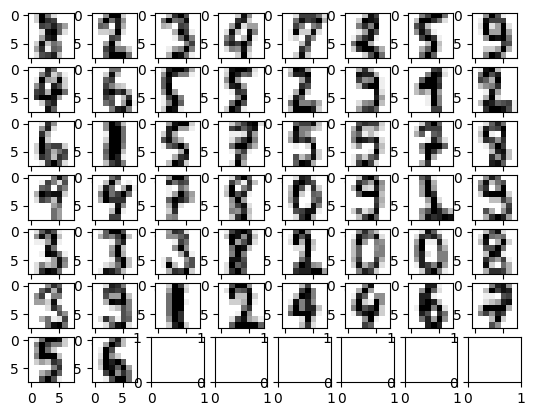

In [108]:
actime_lern = ActiveLearningClassifier(model_file_name='active_50cl.pkl')
lb_inxs = actime_lern.fit(X_train)

In [109]:
labels3 = y_train[lb_inxs]
labels3

array([9, 2, 6, 2, 8, 3, 1, 1, 4, 1, 6, 8, 2, 2, 9, 9, 9, 1, 5, 2, 3, 4,
       3, 4, 1, 3, 4, 4, 5, 9, 3, 2, 9, 3, 7, 0, 7, 5, 6, 6, 8, 7, 5, 7,
       4, 3, 1, 4, 8, 9])

In [110]:
labels == labels3

array([False,  True, False, False, False, False, False, False,  True,
       False, False, False,  True, False, False, False, False,  True,
        True, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False,  True, False, False,
       False, False, False, False, False, False, False, False,  True,
       False, False, False, False, False])

In [111]:
actime_lern = ActiveLearningClassifier(model_file_name='active_50cl.pkl')
actime_lern.fit_labels(labels3)
actime_lern.score(X_test, y_test)

0.8765743073047859

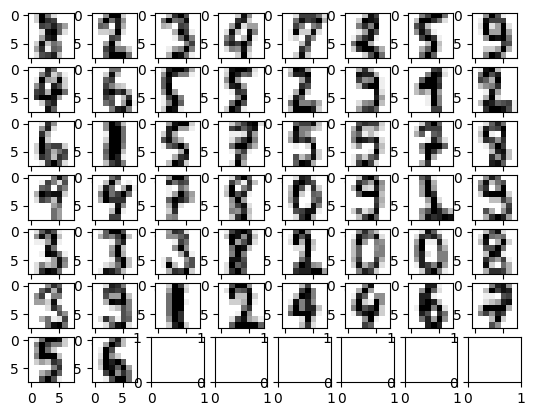

In [112]:
actime_lern = ActiveLearningClassifier(model_file_name='active_50cl.pkl')
lb_inxs = actime_lern.fit(X_train)

In [113]:
labels4 = y_train[lb_inxs]
labels4

array([6, 6, 8, 1, 3, 8, 1, 7, 5, 7, 7, 2, 8, 1, 0, 0, 6, 8, 3, 4, 9, 7,
       4, 2, 1, 3, 6, 1, 8, 2, 1, 7, 5, 2, 1, 4, 2, 9, 7, 0, 4, 5, 3, 5,
       6, 4, 1, 3, 4, 2])

In [114]:
labels3 == labels4

array([False, False, False, False, False, False,  True, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False])

In [115]:
actime_lern = ActiveLearningClassifier(model_file_name='active_50cl.pkl')
actime_lern.fit_labels(labels4)
actime_lern.score(X_test, y_test)

0.8740554156171285

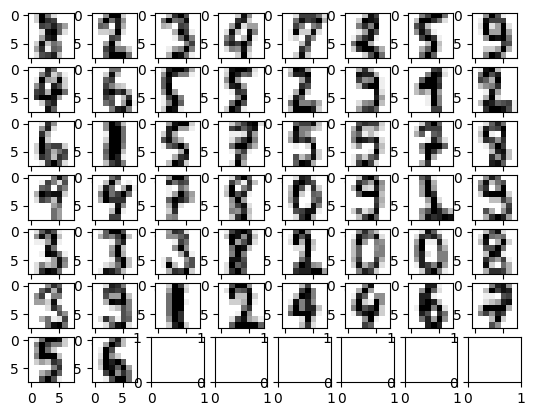

In [116]:
actime_lern = ActiveLearningClassifier(model_file_name='active_50cl.pkl')
lb_inxs = actime_lern.fit(X_train)

In [117]:
labels5 = y_train[lb_inxs]
labels5

array([6, 1, 7, 4, 5, 3, 4, 9, 9, 7, 5, 8, 1, 5, 6, 8, 5, 2, 6, 8, 6, 1,
       2, 3, 2, 7, 5, 3, 4, 7, 7, 3, 1, 2, 9, 1, 6, 3, 7, 9, 7, 5, 0, 9,
       8, 9, 1, 0, 0, 1])

In [118]:
labels4 == labels5

array([ True, False, False, False, False, False, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True, False, False,
       False, False,  True, False, False,  True, False, False, False,
       False,  True, False, False, False])

In [119]:
actime_lern = ActiveLearningClassifier(model_file_name='active_50cl.pkl')
actime_lern.fit_labels(labels5)
actime_lern.score(X_test, y_test)

0.8866498740554156

## Task 4

In [137]:
from sklearn.linear_model import LogisticRegression

KMeansLearningClassifier

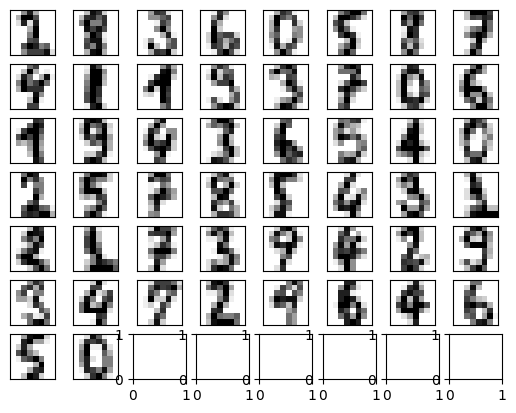

In [132]:
reload(semi_supervised_alg)
from semi_supervised_alg import KMeansLearningClassifier

kmeans_lerning = KMeansLearningClassifier(50, 'task4.pkl', plot_digit, 42, test=True)
lb_inxs = kmeans_lerning.fit(X_train)

In [133]:
kmeans_lerning_lb = y_train[lb_inxs]
kmeans_lerning_lb

array([2, 8, 3, 6, 0, 5, 8, 7, 4, 1, 1, 9, 3, 7, 0, 6, 1, 9, 4, 3, 6, 5,
       4, 0, 2, 5, 7, 8, 5, 4, 3, 1, 2, 1, 7, 3, 9, 4, 2, 9, 3, 4, 7, 2,
       9, 6, 4, 6, 5, 0])

In [134]:
kmeans_lerning = KMeansLearningClassifier(model_file_name='task4.pkl')
kmeans_lerning.fit_labels(kmeans_lerning_lb)
kmeans_lerning_score = kmeans_lerning.score(X_test, y_test)
kmeans_lerning_score

0.8841309823677582

In [135]:
kmeans_lb = kmeans_lerning.y_train_propagated_
kmeans_label_score = (kmeans_lb == y_train).mean()
kmeans_label_score

np.float64(0.9528571428571428)

SelfTrainingClassifier

In [141]:
reload(semi_supervised_alg)
from semi_supervised_alg import SelfTrainingClassifier

self_train = SelfTrainingClassifier(LogisticRegression(max_iter=1000, random_state=42)).fit(X_train, y_train_50_lb)
self_train_score = self_train.score(X_test, y_test)
print(self_train_score)

mask = self_train.transduction_ != -1
self_train_lb_score = (self_train.transduction_[mask] == y_train[mask]).mean()
print(self_train_lb_score)

0.72544080604534
0.8194945848375451


LabelSpreading

In [ ]:
from sklearn.semi_supervised import LabelSpreading

lbl_spred = LabelSpreading(n_neighbors=5, gamma=0.25).fit(X_train, y_train_50_lb)
lbl_spred_score = lbl_spred.score(X_test, y_test)
print(lbl_spred_score)

lbl_spred_lb_score = (lbl_spred.transduction_ == y_train).mean()
print(lbl_spred_lb_score)

0.8085642317380353
0.865


LabelPropagation

In [168]:
from sklearn.semi_supervised import LabelPropagation

lbl_prop = LabelPropagation(n_neighbors=7, gamma=0.25).fit(X_train, y_train_50_lb)
lbl_prop_score = lbl_prop.score(X_test, y_test)
print(lbl_prop_score)

lbl_prop_lb_score = (lbl_prop.transduction_ == y_train).mean()
print(lbl_prop_lb_score)

0.7481108312342569
0.7978571428571428


In [176]:
log_reg = LogisticRegression(max_iter=1_000).fit(X_train, y_train)
log_reg_score = log_reg.score(X_test, y_test)
log_reg_score

0.9093198992443325

In [177]:
import pandas as pd

rows = [
    'KMeansLearningClassifier',
    'ActiveLearningClassifier',
    'SelfTrainingClassifier',
    'LabelSpreading',
    'LabelPropagation',
]

cols = ['Model Score', 'Label Score']

data = [
    [kmeans_lerning_score, kmeans_label_score],
    [log_reg_score, 1],
    [self_train_score, self_train_lb_score],
    [lbl_spred_score, lbl_spred_lb_score],
    [lbl_prop_score, lbl_prop_lb_score],
]

pd.DataFrame(data, rows, cols)

,Model Score,Label Score
KMeansLearningClassifier,0.884131,0.952857
ActiveLearningClassifier,0.909320,1.000000
SelfTrainingClassifier,0.725441,0.819495
LabelSpreading,0.808564,0.865000
LabelPropagation,0.748111,0.797857
